[Click here to view the Dashboard](https://public.tableau.com/views/ABTestFinal/Overview?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## 📊 Environment Setup

This section prepares the Python environment, installs required libraries,
authenticates the user, and initializes the BigQuery client.

In [ ]:
!pip install --quiet google-cloud-bigquery pandas pyarrow

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
client = bigquery.Client(project="data-analytics-mate")
print("Connected to BigQuery", client.project)

Connected to BigQuery data-analytics-mate


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import ( ttest_ind,
                         pearsonr,
                         shapiro,
                         mannwhitneyu,
                         kruskal,
                         chi2_contingency)
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
query = "Select 1 AS ok"
df = client.query(query).to_dataframe()
df

,ok
0,1


In [ ]:
tables = client.list_tables("data-analytics-mate.DA")
[t.table_id for t in tables]

['ab_test',
 'account',
 'account_session',
 'email_open',
 'email_sent',
 'email_visit',
 'event_params',
 'order',
 'paid_search_cost',
 'product',
 'revenue_predict',
 'session',
 'session_params']

## 📊 Data Validation – Raw Tables

In [ ]:
query = """
SELECT *
FROM `data-analytics-mate.DA.session_params`
LIMIT 10
"""
df = client.query(query).to_dataframe()
df


,ga_session_id,device,mobile_model_name,operating_system,language,browser,continent,country,medium,name,channel
0,7268004754,desktop,Chrome,Web,en-gb,Chrome,(not set),(not set),(none),(direct),Direct
1,8321293308,desktop,Chrome,Web,None,Chrome,(not set),(not set),(none),(direct),Direct
2,4392362373,desktop,Chrome,Web,None,Chrome,(not set),(not set),organic,(organic),Organic Search
3,140108698,desktop,Safari,Web,en-us,Chrome,(not set),(not set),(none),(direct),Direct
4,8351127264,mobile,iPhone,Web,en-us,Safari,(not set),(not set),organic,(organic),Organic Search
5,7025645673,mobile,<Other>,Web,en-gb,<Other>,(not set),(not set),(none),(direct),Direct
6,3870944488,mobile,<Other>,Web,None,Chrome,(not set),(not set),(none),(direct),Direct
7,2832302521,mobile,<Other>,Web,None,Chrome,(not set),(not set),organic,(organic),Organic Search
8,9021253377,mobile,<Other>,Web,en-us,Chrome,(not set),(not set),organic,(organic),Organic Search
9,5677591798,mobile,<Other>,Web,en-gb,<Other>,(not set),(not set),referral,(referral),Paid Search


In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
language,0.4
device,0.0
ga_session_id,0.0
mobile_model_name,0.0
operating_system,0.0
browser,0.0
continent,0.0
country,0.0
medium,0.0
name,0.0


In [ ]:
query = """
WITH base AS (
  SELECT
  sp.ga_session_id AS session_id,
  sp.country,
  sp.continent,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name,
  sp.medium,
  sp.channel
  FROM `data-analytics-mate.DA.session_params` AS sp
),
acc AS (
  SELECT
  accs.ga_session_id AS session_id,
  a.id,
  a.is_verified,
  a.is_unsubscribed = 0 AS is_subscribed
  FROM `data-analytics-mate.DA.account_session` AS accs
  LEFT JOIN `data-analytics-mate.DA.account` AS a
   ON accs.account_id = a.id
),
ord AS (
  SELECT
  o.ga_session_id AS session_id,
  p.category,
  p.name AS product_name,
  p.price,
  p.short_description
  FROM `data-analytics-mate.DA.order` AS o
  LEFT JOIN `data-analytics-mate.DA.product` AS p
   ON o.item_id = p.item_id
),
order_dt AS (
  SELECT
  ga_session_id AS session_id,
  DATE(TIMESTAMP_MICROS(MIN(event_timestamp))) AS order_date
  FROM `data-analytics-mate.DA.event_params`
  WHERE event_name IN (
    'begin_checkout',
    'add_payment_info',
    'add_shipping_info'
  )
  GROUP BY 1
)

  SELECT
  od.order_date,
  b.*,
  a.id,
  a.is_verified,
  a.is_subscribed,
  o.category,
  o.product_name,
  o.price,
  o.short_description
  FROM base AS b
  LEFT JOIN order_dt AS od USING(session_id)
  LEFT JOIN acc AS a USING(session_id)
  LEFT JOIN ord o USING(session_id)
"""

df_final = client.query(query).to_dataframe()
df_final.describe()

,session_id,id,is_verified,price
count,349545.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,953.298679
std,2887450949.537772,13216.529465,0.450474,1317.001775
min,1205.0,636133.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,445.000000
75%,7491286508.0,670414.0,1.0,1195.000000
max,9999997129.0,681962.0,1.0,9585.000000


In [ ]:
df_final["session_id"].value_counts().head()

,count
session_id,
3546986325,1
1274911109,1
8300901126,1
3017617387,1
7037735941,1


In [ ]:
print("Rows:", len(df_final))
print("Unique sessions:", df_final["session_id"].nunique())

Rows: 349545
Unique sessions: 349545


## 📊 Data Validation – Final Dataset

In [ ]:
df_final["order_date"] = pd.to_datetime(df_final["order_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date         11091 non-null   datetime64[ns]
 1   session_id         349545 non-null  Int64         
 2   country            349545 non-null  object        
 3   continent          349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   language           235279 non-null  object        
 9   name               349545 non-null  object        
 10  medium             349545 non-null  object        
 11  channel            349545 non-null  object        
 12  id                 27945 non-null   Int64         
 13  is_verified        27945 non-null   Int64   

In [ ]:
orders_dates = df_final["order_date"].dropna()
print("Order date range:")
print(orders_dates.min(), "->", orders_dates.max())

Order date range:
2020-11-01 00:00:00 -> 2021-01-31 00:00:00


## 📊 Dataset Overview

- Rows: **349,545**
- Columns: **19**
- Unique sessions: **349,545**
- Order date range: **2020-11-01 -> 2021-01-31**

Each row represents a unique user session.

---

## 🔢 Column Types

- Datetime: `order_date`
- Numeric: `session_id`, `id`, `is_verified`, `price`
- Boolean: `is_subscribed`
- Categorical: `country`, `continent`, `device`, `browser`,
  `mobile_model_name`, `operating_system`, `language`,
  `name`, `medium`, `channel`, `category`,
  `product_name`, `short_description`

---

## ❗ Missing Values

The presence of missing values is consistent with the dataset design:

- Order information is available exclusively for sessions with completed purchases  
- User attributes are recorded only for authenticated (registered) users  
- Product details are populated only when a transaction occurred  

Therefore, missing values reflect the natural sparsity of behavioral and transactional data rather than data inconsistencies.

## 📊 Top Continents & Countries by Revenue

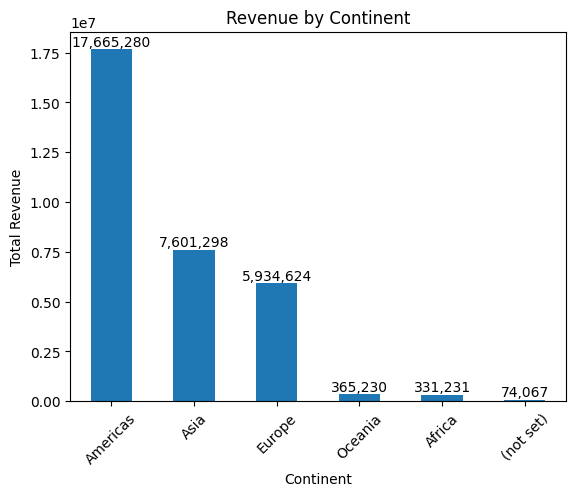

In [ ]:
continent_revenue = (
    df_final.dropna(subset=["price"])
    .groupby("continent")["price"]
    .sum()
    .sort_values(ascending=False))

plt.figure()
ax = continent_revenue.plot(kind="bar")
plt.title("Revenue by Continent")
plt.ylabel("Total Revenue")
plt.xlabel("Continent")
plt.xticks(rotation=45)
for i, v in enumerate(continent_revenue):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')
plt.show()

In [ ]:
continent_share = continent_revenue / continent_revenue.sum() * 100
continent_share

,price
continent,
Americas,55.252811
Asia,23.775060
Europe,18.562098
Oceania,1.142354
Africa,1.036012
(not set),0.231665


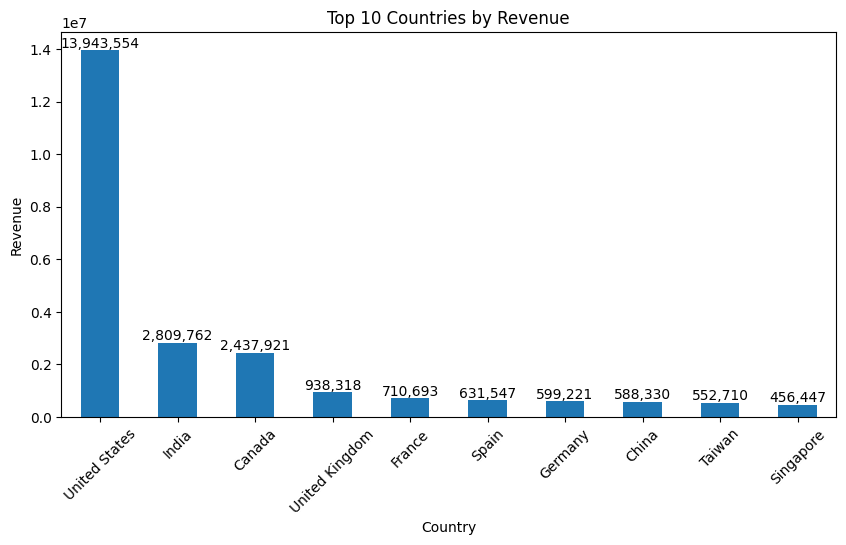

In [ ]:
country_rev = df_final.groupby("country")["price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
ax=country_rev.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
for i, v in enumerate(country_rev):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.show()

**Conclusion:** Revenue concentration analysis shows that 55.3% of total revenue comes from the Americas.
Asia (23.8%) represents a strong secondary region with growth potential, while Europe (18.6%) shows stable but comparatively lower performance.

Other regions (Oceania, Africa) contribute minimally (<2%), indicating either limited market presence or lower customer activity.

Overall, the business appears regionally dependent on the Americas, suggesting both strength (market leadership) and risk (geographic concentration).

## 📊 Sales by Device Type (%)

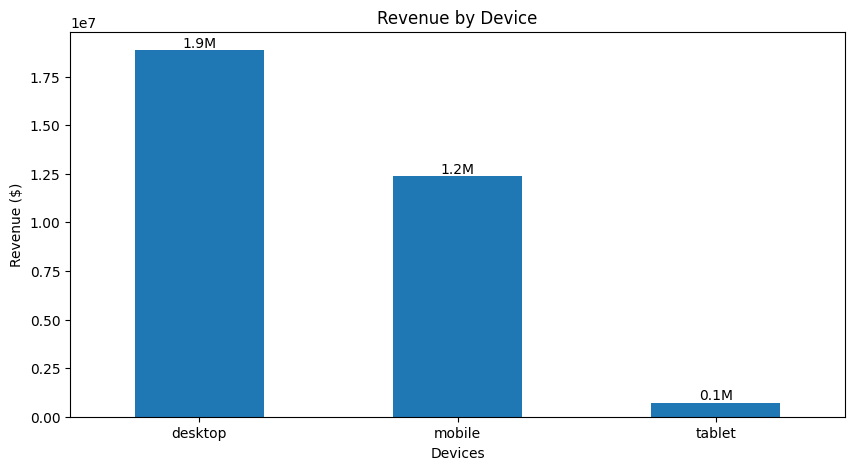

In [ ]:
device_rev = (
    df_final.groupby("device")["price"]
      .sum()
      .sort_values(ascending=False))

plt.figure(figsize=(10,5))

ax = device_rev.plot(kind="bar")

plt.title("Revenue by Device")
plt.ylabel("Revenue ($)")
plt.xlabel("Devices")
plt.xticks(rotation=0)

for i, v in enumerate(device_rev):
    ax.text(i, v, f"{v/1e7:.1f}M", ha='center', va='bottom')

plt.show()

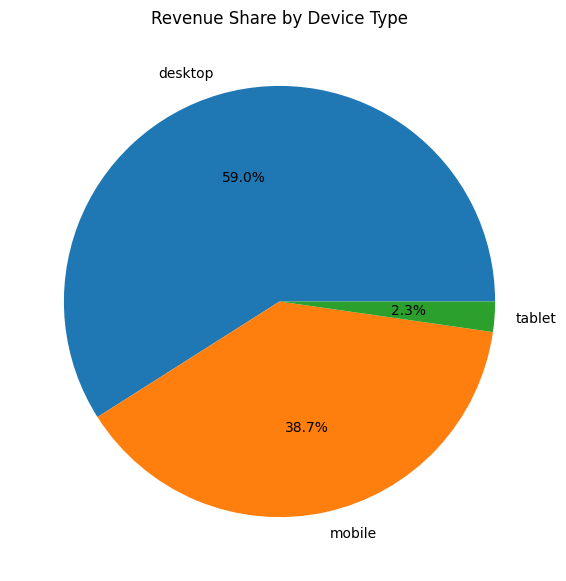

In [ ]:
device_share = device_rev / device_rev.sum() * 100

plt.figure(figsize=(7,7))

plt.pie(
    device_share,
    labels=device_share.index,
    autopct='%1.1f%%')

plt.title("Revenue Share by Device Type")
plt.show()

## 📊 Top Product Categories by Revenue

In [ ]:
df_final['category'].unique()

array([None, 'Chairs', 'Sofas & armchairs', 'Nursery furniture',
       'Cabinets & cupboards', 'Bookcases & shelving units',
       'Outdoor furniture', 'Chests of drawers & drawer units', 'Beds',
       'Bar furniture', 'Tables & desks', "Children's furniture",
       'Sideboards, buffets & console tables', 'Café furniture',
       'Room dividers'], dtype=object)

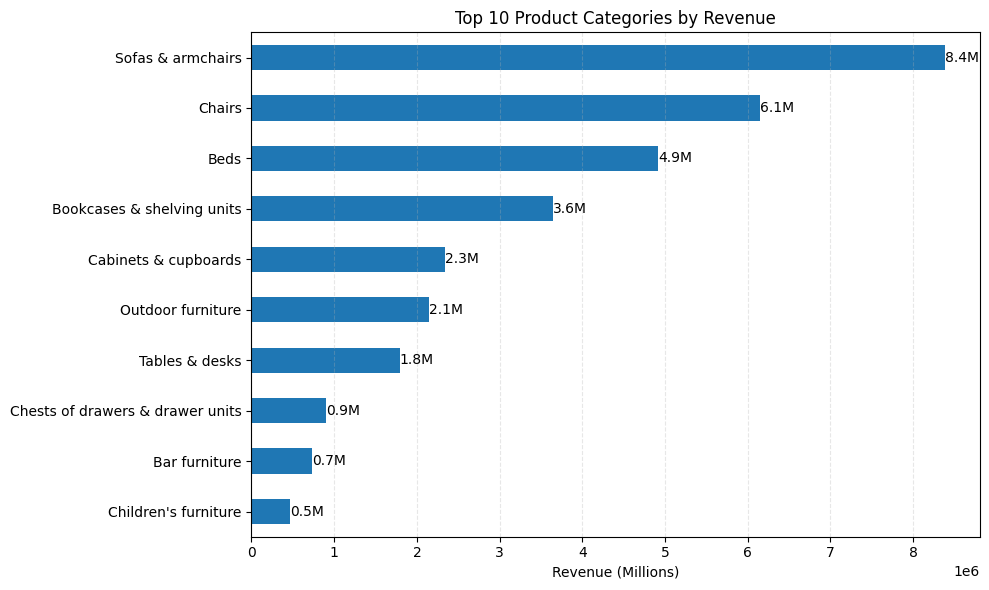

In [ ]:
top_cat = (
    df_final.groupby("category")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10))

plt.figure(figsize=(10,6))
ax = top_cat.plot(kind="barh")

ax.invert_yaxis()

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (Millions)")
plt.ylabel("")

for i, v in enumerate(top_cat):
    ax.text(v, i, f"{v/1e6:.1f}M", va="center")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:**
Revenue is concentrated in a few dominant categories, led by Sofas & Armchairs, Chairs, and Beds.

**Implication:**
These categories are the primary revenue drivers and should be prioritized in marketing and inventory strategy.

## 📊 Sales by Traffic Channel (%)

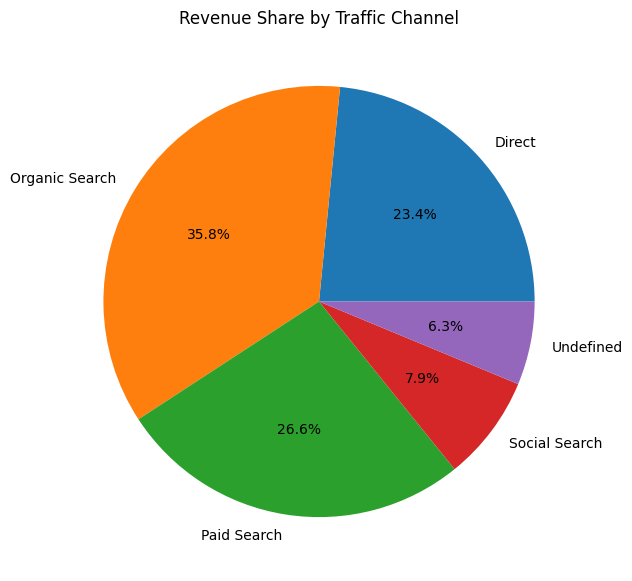

In [ ]:
channel_rev = df_final.groupby("channel")["price"].sum()
channel_share = channel_rev / channel_rev.sum() * 100

plt.figure(figsize=(7,7))
plt.pie(channel_share, labels=channel_share.index, autopct='%1.1f%%')
plt.title("Revenue Share by Traffic Channel")
plt.show()

**Insight:**
Organic Search is the leading revenue driver (35.8%), followed by Paid Search (26.6%) and Direct traffic (23.4%). Social channels contribute a relatively small share (7.9%), while Undefined traffic accounts for 6.3%.

**Implication:**
The business heavily depends on search-based acquisition. Maintaining SEO performance and optimizing paid search campaigns are critical for revenue stability. Social traffic may represent a growth opportunity if conversion efficiency can be improved.


## 👥 Verification Rate of Registered Users

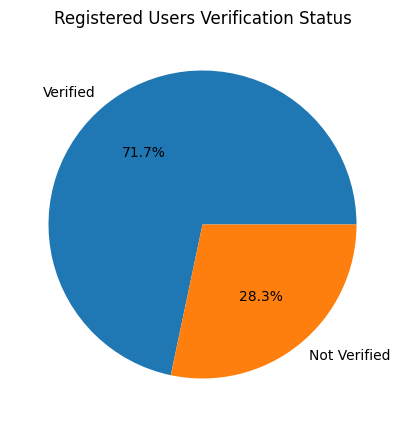

In [ ]:
verified_counts = df_final["is_verified"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    verified_counts,
    labels=["Verified", "Not Verified"],
    autopct='%1.1f%%')

plt.title("Registered Users Verification Status")
plt.show()

**Insight:**
Approximately 71.7% of registered users are verified, indicating a relatively high verification completion rate.

**Implication:**
The majority of users complete the verification process, suggesting that onboarding friction is moderate. However, nearly 28% remain unverified, representing potential risks for trust, personalization, or conversion.

**Actionable takeaway:**
Investigate barriers in the verification funnel to capture additional verified users and improve engagement quality.

## 👥 Behavior Between Subscribed and Unsubscribed Users

In [ ]:
from scipy.stats import ttest_ind
import numpy as np

registered_users = df_final[df_final["id"].notna()]

subscribed = registered_users[registered_users["is_subscribed"] == True]["price"]
unsubscribed = registered_users[registered_users["is_subscribed"] == False]["price"]

sub_mean = subscribed.mean()
unsub_mean = unsubscribed.mean()
diff = sub_mean - unsub_mean
pct_diff = diff / unsub_mean * 100

print("Descriptive Statistics")
print("-" * 50)
print(f"Subscribed users:   mean = {sub_mean:.2f}, n = {len(subscribed)}")
print(f"Unsubscribed users: mean = {unsub_mean:.2f}, n = {len(unsubscribed)}")
print(f"Difference (Sub - Unsub): {diff:.2f} ({pct_diff:.2f}%)")

t_stat, p_value = ttest_ind(subscribed, unsubscribed, nan_policy='omit')

print("\nT-test Results")
print("-" * 50)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.5f}")

def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

d = cohens_d(subscribed, unsubscribed)

print(f"\nEffect Size (Cohen’s d): {d:.3f}")

alpha = 0.05
print("\nInterpretation")
print("-" * 50)

if p_value < alpha:
    print("Revenue difference is statistically significant.")
else:
    print("No statistically significant revenue difference detected.")

if abs(d) < 0.2:
    print("Effect size: negligible.")
elif abs(d) < 0.5:
    print("Effect size: small.")
elif abs(d) < 0.8:
    print("Effect size: medium.")
else:
    print("Effect size: large.")


Descriptive Statistics
--------------------------------------------------
Subscribed users:   mean = 921.51, n = 23210
Unsubscribed users: mean = 965.82, n = 4735
Difference (Sub - Unsub): -44.31 (-4.59%)

T-test Results
--------------------------------------------------
T-statistic: -0.650
P-value:     0.51554

Effect Size (Cohen’s d): -0.034

Interpretation
--------------------------------------------------
No statistically significant revenue difference detected.
Effect size: negligible.


### 📌 Subscribed vs Unsubscribed Users

Although unsubscribed users show a slightly higher average revenue,
the difference is **not statistically significant** (p > 0.05).

The negligible effect size (Cohen’s d ≈ 0) indicates that
subscription status has **no practical impact on revenue**.

**Business Insight:**
Email subscription alone does not appear to influence purchasing behavior.
Its value may lie in engagement, communication, or retention rather than direct revenue generation.

## **📊** Overall Revenue Trend

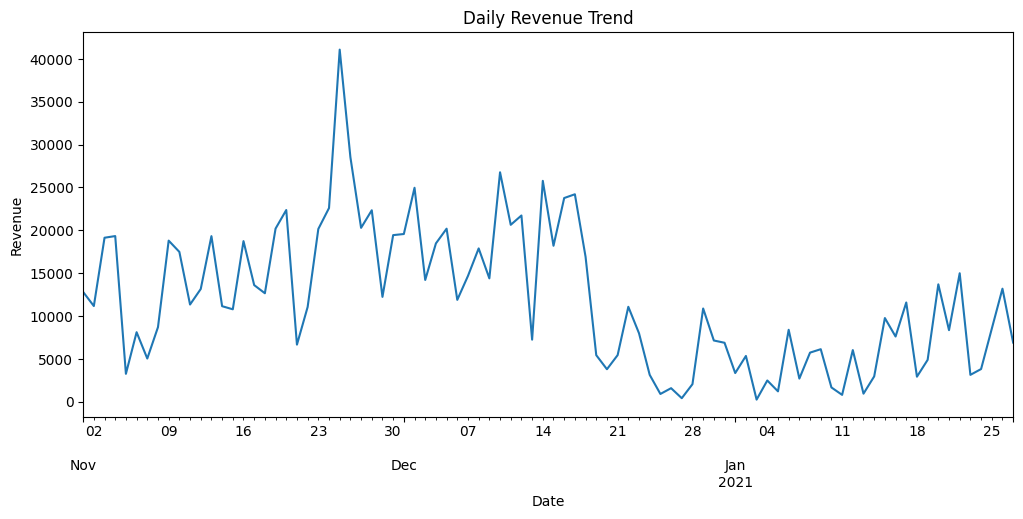

In [ ]:
daily_rev = (
    df_final.dropna(subset=["price"])
      .groupby("order_date")["price"]
      .sum())

plt.figure(figsize=(12,5))
daily_rev.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

**Insight:**
Daily revenue displays noticeable fluctuations over time, indicating variability in customer purchasing behavior.

**Implication:**
Revenue volatility may be influenced by seasonality, promotional activity, or shifting demand patterns, requiring deeper temporal analysis.


## 📅 Revenue Seasonality (Monthly Analysis)

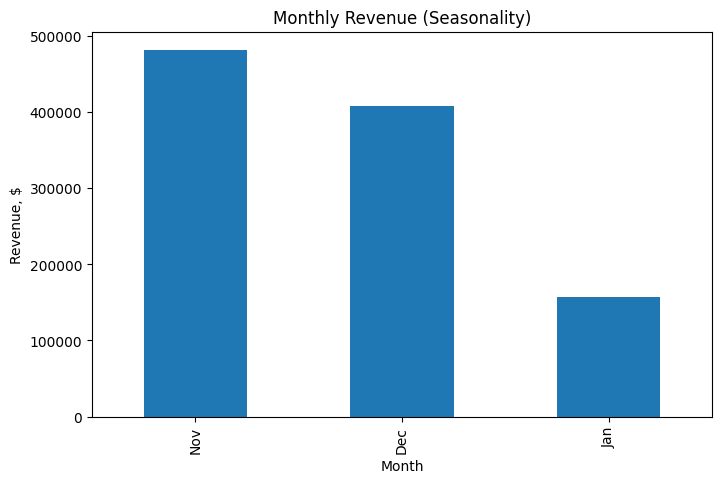

In [ ]:
df_final["month_name"] = df_final["order_date"].dt.strftime("%b")

monthly_rev = (
    df_final.dropna(subset=["price"])
      .groupby("month_name")["price"]
      .sum())

monthly_rev = monthly_rev.reindex(["Nov", "Dec", "Jan"])

plt.figure(figsize=(8,5))
monthly_rev.plot(kind="bar")
plt.title("Monthly Revenue (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Revenue, $")
plt.show()

**Insight:**
Monthly revenue peaks in November, followed by a moderate decline in December and a substantial decrease in January.

**Implication:**
This pattern suggests short-term seasonality, potentially driven by increased pre-holiday purchasing activity and reduced customer spending after the holiday period.

## 🌎 Revenue Trend by Continent?

<Axes: xlabel='order_date'>

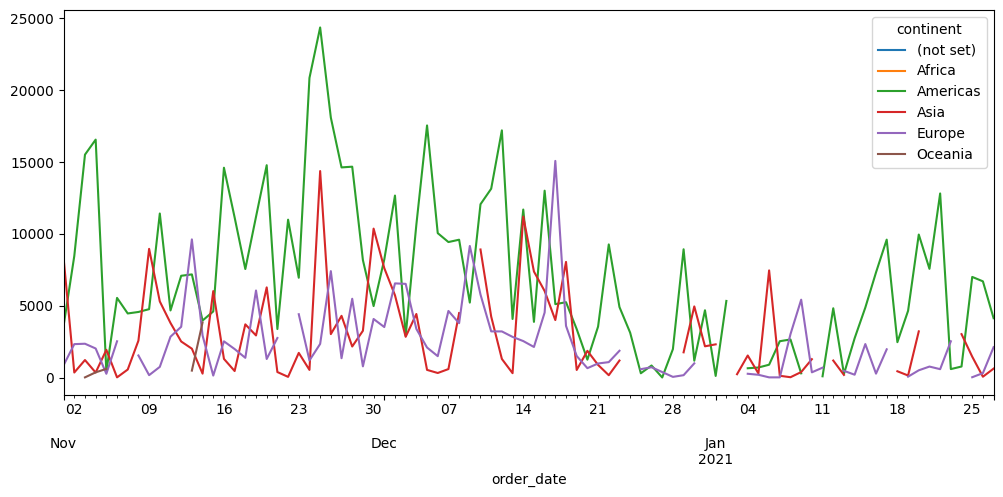

In [ ]:
continent_trend = (
    df_final.dropna(subset=["price"])
      .groupby(["order_date", "continent"])["price"]
      .sum()
      .unstack())
continent_trend.plot(figsize=(12,5))

**Insight:**
The Americas consistently generate the highest revenue throughout the observed period. Europe and Asia contribute smaller yet fluctuating revenue streams, while Africa and Oceania show minimal impact.

**Implication:**
Revenue concentration in the Americas indicates strong regional performance but highlights potential geographic dependency risk. Lower-revenue regions may represent long-term expansion opportunities.

**Data Quality Note:**
The presence of “not set” continent values indicates incomplete geographic classification, which may slightly distort regional comparisons.

## 📋 Sessions by Channel & Device

In [ ]:
sessions_pivot = pd.pivot_table(
    df_final,
    values="session_id",
    index="channel",
    columns="device",
    aggfunc=pd.Series.nunique
).fillna(0).astype(int)

display(
    sessions_pivot
      .sort_values(by=sessions_pivot.columns.tolist(), ascending=False)
      .style
      .format("{:,.0f}"))

device,desktop,mobile,tablet
channel,,,
Organic Search,"72,622","49,014","2,789"
Paid Search,"55,167","37,034","2,140"
Direct,"47,825","31,745","1,812"
Social Search,"16,288","10,988",638
Undefined,"12,527","8,486",470


**Insight:**
Organic Search generates the highest number of sessions across all device types. Desktop traffic dominates overall, followed by mobile, while tablet usage remains significantly lower.

**Implication:**
Search-driven acquisition is the primary source of user traffic. The strong desktop presence suggests that users may prefer browsing or researching products on larger screens.

## 🌍 Sales by Category & Country

(Top-10 Categories & Top-5 Countries)


In [ ]:
df_sales = df_final.dropna(subset=["price"]).copy()

top_categories = (
    df_sales.groupby("category")["price"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
            .index)

top_countries = (
    df_sales.groupby("country")["price"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
            .index)

pivot_cat_country = pd.pivot_table(
    df_sales[df_sales["category"].isin(top_categories) & df_sales["country"].isin(top_countries)],
    values="price",
    index="category",
    columns="country",
    aggfunc="sum"
).fillna(0)

display(
    pivot_cat_country
      .style
      .format("{:,.0f}"))

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,"51,724","11,199","57,657","22,103","330,805"
Beds,"354,772","116,414","358,320","133,816","2,213,058"
Bookcases & shelving units,"278,982","73,830","364,507","113,988","1,567,607"
Cabinets & cupboards,"181,802","59,102","191,888","71,684","994,546"
Chairs,"417,741","134,029","544,309","188,519","2,619,774"
Chests of drawers & drawer units,"71,952","21,544","73,111","36,784","382,388"
Children's furniture,"30,264","14,258","39,177","13,348","207,575"
Outdoor furniture,"185,323","40,486","162,289","57,002","929,245"
Sofas & armchairs,"692,428","187,735","788,430","234,812","3,707,144"


**Insight:**
Revenue distribution varies across product categories and countries. Sofas & Armchairs, Chairs, and Beds consistently generate high revenue across major markets, particularly in the United States.

**Implication:**
Core furniture categories represent the main revenue drivers. Geographic differences indicate varying customer preferences, highlighting the importance of localized assortment and pricing strategies.

## 📊 Revenue & Conversion by Device

In [ ]:
device_metrics = df_final.groupby("device").agg(
    revenue=("price", "sum"),
    sessions=("session_id", "nunique"))

orders_by_device = (
    df_final.dropna(subset=["price"])
      .groupby("device")["session_id"]
      .nunique())

device_metrics["conversion_rate"] = (orders_by_device / device_metrics["sessions"]) * 100

device_metrics_clean = device_metrics.rename(columns={
    "revenue": "Revenue ($)",
    "sessions": "Sessions",
    "conversion_rate": "Conversion Rate"
}).sort_values(by="Revenue ($)", ascending=False)

display(
    device_metrics_clean
      .style
      .format({
          "Revenue ($)": "{:,.0f}",
          "Sessions": "{:,.0f}",
          "Conversion Rate": "{:.2f}%"}))

,Revenue ($),Sessions,Conversion Rate
device,,,
desktop,"18,864,039","204,429",9.64%
mobile,"12,384,226","137,267",9.55%
tablet,"723,466","7,849",9.21%


**Insight:**
Desktop devices generate the highest revenue despite conversion rates being nearly identical between desktop and mobile. Tablet devices contribute minimally to total revenue.

**Implication:**
While desktop remains the dominant revenue channel, mobile performance is comparable in terms of conversion efficiency. Enhancing the mobile shopping experience could further increase revenue.

## **Correlation: Sessions vs Revenue**

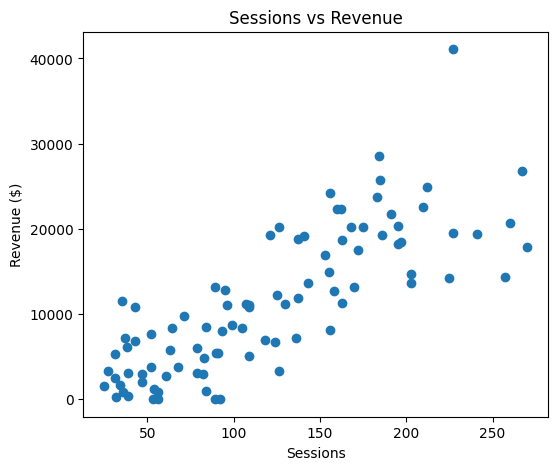

Pearson correlation: 0.800
P-value: 0.00000
Statistically significant correlation detected.
Correlation strength: strong.


,revenue,sessions
order_date,,
2020-11-01,12804.0,95
2020-11-02,11163.0,130
2020-11-03,19133.0,141
2020-11-04,19327.0,121
2020-11-05,3257.0,126


In [ ]:
daily_metrics = (
    df_final.groupby("order_date")
      .agg(
          revenue=("price", "sum"),
          sessions=("session_id", "nunique"))
      .dropna())

plt.figure(figsize=(6,5))
plt.scatter(daily_metrics["sessions"], daily_metrics["revenue"])
plt.title("Sessions vs Revenue")
plt.xlabel("Sessions")
plt.ylabel("Revenue ($)")
plt.show()

corr, p_value = pearsonr(
    daily_metrics["sessions"],
    daily_metrics["revenue"])

print(f"Pearson correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Statistically significant correlation detected.")
else:
    print("No statistically significant correlation detected.")

if abs(corr) < 0.3:
    strength = "weak"
elif abs(corr) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

print(f"Correlation strength: {strength}.")

daily_metrics.head()

A **strong positive correlation (r = 0.80)** was observed between the number of daily sessions and daily revenue.

The **p-value < 0.05** indicates that this relationship is **statistically significant**, meaning the correlation is highly unlikely to be due to random chance.

**This result suggests that:**

- ✔ Higher website traffic is strongly associated with higher revenue
- ✔ Traffic acquisition plays a critical role in sales performance
- ✔ Changes in sessions are likely to impact revenue levels

**The company should:**

- ✅ Continue investing in traffic-driving channels
- ✅ Monitor session trends as a leading indicator of revenue
- ✅ Optimize marketing campaigns that increase qualified traffic

 ## **Correlation Between Top-3 Continents**

In [ ]:
top_continents = (
    df_final.groupby("continent")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .index)

continent_daily = (
    df_final[df_final["continent"].isin(top_continents)]
      .groupby(["order_date", "continent"])["price"]
      .sum()
      .unstack()
      .dropna())

continent_daily.head()


continent,Americas,Asia,Europe
order_date,,,
2020-11-01,3612.0,8323.0,869.0
2020-11-02,8465.0,362.0,2336.0
2020-11-03,15514.0,1230.0,2364.0
2020-11-04,16559.0,360.0,2033.0
2020-11-05,427.0,1940.0,275.0


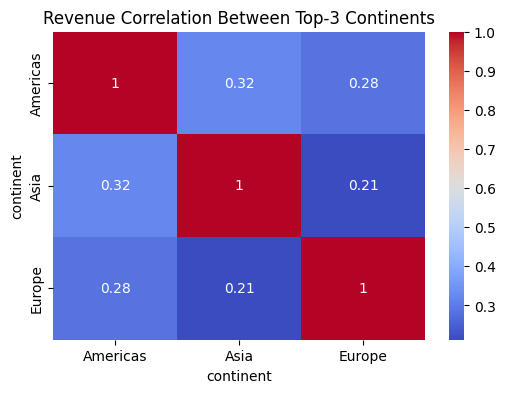

Americas vs Asia
  Correlation: 0.320
  P-value: 0.00186
  → Statistically significant
Americas vs Europe
  Correlation: 0.284
  P-value: 0.00614
  → Statistically significant
Asia vs Europe
  Correlation: 0.212
  P-value: 0.04218
  → Statistically significant


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.320185,0.283679
Asia,0.320185,1.000000,0.212307
Europe,0.283679,0.212307,1.000000


In [ ]:
corr_matrix = continent_daily.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Revenue Correlation Between Top-3 Continents")
plt.show()

continents = continent_daily.columns

for i in range(len(continents)):
    for j in range(i+1, len(continents)):
        c1, c2 = continents[i], continents[j]

        corr, p = pearsonr(
            continent_daily[c1],
            continent_daily[c2])

        print(f"{c1} vs {c2}")
        print(f"  Correlation: {corr:.3f}")
        print(f"  P-value: {p:.5f}")

        if p < 0.05:
            print("  → Statistically significant")
        else:
            print("  → Not statistically significant")
corr_matrix

**Insight:**
While revenue trends across Americas, Asia, and Europe move in the same general direction, the relatively weak correlations indicate that local factors play a substantial role in shaping demand.

**The company should:**

- ✔ Maintain global strategic coordination (single global strategy)
- ✔ BUT apply localized marketing & sales strategies (regional optimization needed)

 ## **Revenue Difference (Registered vs Guest Users)**

In [ ]:
registered_rev = df_final[
    (df_final["is_subscribed"] == True) & (df_final["price"].notna())
]["price"]

guest_rev = df_final[
    (df_final["is_subscribed"] == False) & (df_final["price"].notna())
]["price"]

print("Registered sample size:", len(registered_rev))
print("Guest sample size:", len(guest_rev))

Registered sample size: 2334
Guest sample size: 447


In [ ]:
shapiro_reg = shapiro(registered_rev.sample(min(5000, len(registered_rev))))
shapiro_guest = shapiro(guest_rev.sample(min(5000, len(guest_rev))))

print("Registered p-value:", shapiro_reg.pvalue)
print("Guest p-value:", shapiro_guest.pvalue)

Registered p-value: 6.810968784476697e-56
Guest p-value: 1.1328534757663367e-27


In [ ]:
stat, p_value = mannwhitneyu(
    registered_rev,
    guest_rev,
    alternative="two-sided"
)

print(f"Test statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

Test statistic: 500198.00
P-value: 0.16780


In [ ]:
if p_value < 0.05:
    print("Statistically significant revenue difference detected.")
else:
    print("No statistically significant revenue difference detected.")

No statistically significant revenue difference detected.



**Results:**
- Although averages may differ visually, the difference is not statistically reliable
- User registration status does not significantly affect purchase value

**Business Insights:**

- Guests generate revenue comparable to registered users
- Registration incentives should focus on:

	•	retention
	•	loyalty
	•	lifetime value (LTV)

Rather than immediate revenue increase

 ## **Sessions Difference Across Traffic Channels**

In [ ]:
sessions_by_channel = (
    df_final.groupby("channel")["session_id"]
      .nunique()
      .sort_values(ascending=False))

channel_groups = [
    df_final[df_final["channel"] == ch]["session_id"]
      .dropna()
    for ch in df_final["channel"].dropna().unique()]

sessions_by_channel

,session_id
channel,
Organic Search,124425
Paid Search,94341
Direct,81382
Social Search,27914
Undefined,21483


In [ ]:
stat, p_value = kruskal(*channel_groups)

print(f"Kruskal-Wallis statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Statistically significant differences between channels.")
else:
    print("No statistically significant differences between channels.")


Kruskal-Wallis statistic: 5.61
P-value: 0.23031
No statistically significant differences between channels.


The Kruskal–Wallis test (H = 5.61, p = 0.230) indicates that there are no statistically significant differences in the number of sessions across marketing channels. While Organic Search shows the highest total sessions, the variability within channels suggests that traffic distributions are not meaningfully different.

**Insights:**
- ✔ Channels perform similarly in attracting sessions
- ✔ No channel clearly dominates in consistent traffic generation
- ✔ Optimization decisions should consider:

	•	conversion rate
	•	revenue per session
	•	CPA / ROAS

— **not sessions alone.**

In [ ]:
contingency = pd.crosstab(df_final["device"], df_final["price"].notna())
chi2, p, dof, expected = chi2_contingency(contingency)

contingency = pd.crosstab(
    df_final["device"],
    df_final["price"].notna())

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 2.04
P-value: 0.36074


A Chi-square test. We checked whether purchases depend on device type.
The results show no meaningful difference that users buy at a similar rate across all devices. The results showed no statistically significant association (χ² = 2.04, p = 0.361)